# Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pygenelab as pgl

In [72]:
import pandas as pd 
import numpy as np
import scanpy as sc
import decoupler as dc

from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap

In [5]:
from Utils import plot_violin_box_combo

# Set Configs

In [91]:
# create output directory
sex = "Female"
cell_type = "Skeleton MuSc"
score_type = "Metabolic"

output_dir = Path(f"Output/{cell_type}/{sex}/{score_type}")
output_dir.mkdir(parents=True, exist_ok=True)

In [92]:
# specify pathway
pathway = "REACTOME_PYRUVATE_METABOLISM"

In [93]:
# specify file prefix
file_prefix = f"{cell_type}_{sex[0]}_{pathway}_Score"

# Load Dataset

In [ ]:
# load dataset
DATASET_PATH = r"/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/adata_harmony_v2_re_annot.h5ad"
adata = sc.read_h5ad(DATASET_PATH)
print(f"Original Dataset Shape: {adata.shape}")

Original Dataset Shape: (86641, 3000)


In [94]:
# subset as specified
adata_subset = pgl.subset_adata_by_obs(adata, filters={"sex": sex[0], "re_annot": "Skeleton MuSc"})
print(f"Shape After Subsetting: {adata_subset.shape}")
display(list(adata_subset.obsm))

Shape After Subsetting: (1144, 3000)


['X_pca',
 'X_pca_harmony',
 'X_scANVI',
 'X_scVI',
 'X_umap',
 'gene_expression_encoding']

# Load Pathways

In [95]:
# load pathway
MICE_ALL_PATHWAYS_PATH = r"/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/msigdb.v2024.1.Mm.symbols.gmt"
pathway_genes = pgl.convert_gmt_to_decoupler_format(MICE_ALL_PATHWAYS_PATH,
                                              include_pathways=[pathway],
                                              gene_origin="mice")
display(pathway_genes.head())

# check if genes are present in adata
genes_in_adata = pgl.check_genes_in_adata(pathway_genes, adata_subset)
print(f"Total Genes: {genes_in_adata['total_genes_checked']}")
print(f"Genes Found: {genes_in_adata['genes_found_in_adata']}")

,source,target
0,REACTOME_PYRUVATE_METABOLISM,Armc8
1,REACTOME_PYRUVATE_METABOLISM,Dlat
2,REACTOME_PYRUVATE_METABOLISM,Dld
3,REACTOME_PYRUVATE_METABOLISM,Fahd1
4,REACTOME_PYRUVATE_METABOLISM,Gid4


Total Genes: 45
Genes Found: 4


# Calculate Scores

In [97]:
%%time 

# calculate scores
dc.mt.aucell(
    adata_subset,
    pathway_genes,
    raw=False,
    verbose=True,
    tmin=4
)

2026-06-09 11:45:01 | [INFO] aucell - Running aucell
2026-06-09 11:45:01 | [INFO] Extracted omics mat with 1144 rows (observations) and 3000 columns (features)
2026-06-09 11:45:01 | [WARNING] 553 features of mat are empty, they will be removed
2026-06-09 11:45:01 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026-06-09 11:45:01 | [INFO] Network has 4 unique features and 1 unique sources
2026-06-09 11:45:01 | [INFO] aucell - calculating 1 AUCs for 2447 targets across 1144 observations, categorizing features at rank=123
  0%|          | 0/1144 [00:00<?, ?it/s]

100%|██████████| 1144/1144 [00:00<00:00, 2519.92it/s]
2026-06-09 11:45:01 | [INFO] aucell - done


CPU times: user 26.5 s, sys: 8.98 ms, total: 26.5 s
Wall time: 550 ms


In [98]:
# save scores to obs
display(adata_subset.obsm["score_aucell"][pathway].head())
adata_subset.obs[pathway] = adata_subset.obsm["score_aucell"][pathway].copy()

AACACACGTGTATTGC-1    0.101660
AACTTCTGTTGCATGT-1    0.000000
AAGTACCTCGTTTACT-1    0.203320
AAGTGAATCCACTTCG-1    0.000000
AAGTTCGGTTCTGAGT-1    0.195021
Name: REACTOME_PYRUVATE_METABOLISM, dtype: float64

# Generate Box And Violin Plot

In [99]:
# get plot data
group_score_df = pgl.prepare_group_score_df(adata_subset, group_col="condition", value_col=pathway)
cliffs_delta_df, _ = pgl.calculate_score_cliffs_delta(adata=adata_subset,
                                                        score_col=pathway,
                                                        group_col="condition",
                                                        group1="KO",
                                                        group2="WT")
cliffs_delta = cliffs_delta_df["cliffs_delta"].iloc[0]
higher_group = cliffs_delta_df["higher_group"].iloc[0]

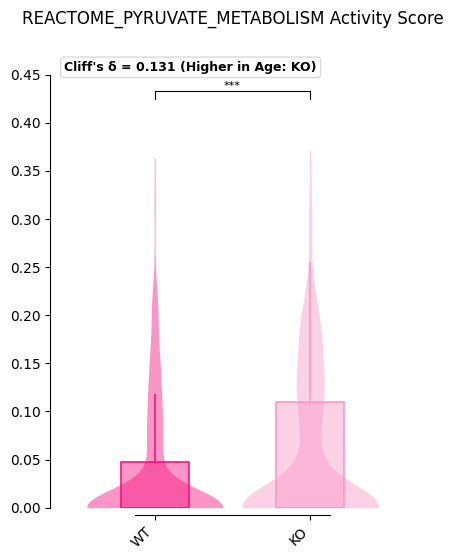

<Figure size 640x480 with 0 Axes>

In [ ]:
# plot
PALETTE = {
    "WT": "#F71480",
    "KO": "#FA98C7"}

fig_violin_box = plot_violin_box_combo(group_score_df, 
                            x_var="condition", 
                            y_var=pathway,
                            x_ticks=["WT", "KO"],
                            palette=PALETTE,
                            title=f"{sex} {cell_type} {pathway}: Activity Score",
                            show_scatter=False,
                            show_pvalue=False,
                            group_spacing=0.8,
                            delta_label=f"Cliff's δ = {round(cliffs_delta, 3)} (Higher in Age: {higher_group})")

display(fig_violin_box)

# Generate Gene Contribution Heatmap

,gene,spearman_corr,rank
0,Pdlim5,0.417443,1
1,Cd36,0.408018,2
2,Pdk4,0.404388,3
3,Tgfb2,0.173817,4
4,Man1a,0.173215,5


,gene,spearman_corr,rank
0,Pdk4,0.485391,1
1,Pdlim5,0.474607,2
2,Aox1,0.277866,3
3,Npc1,0.264308,4
4,Cd36,0.254330,5


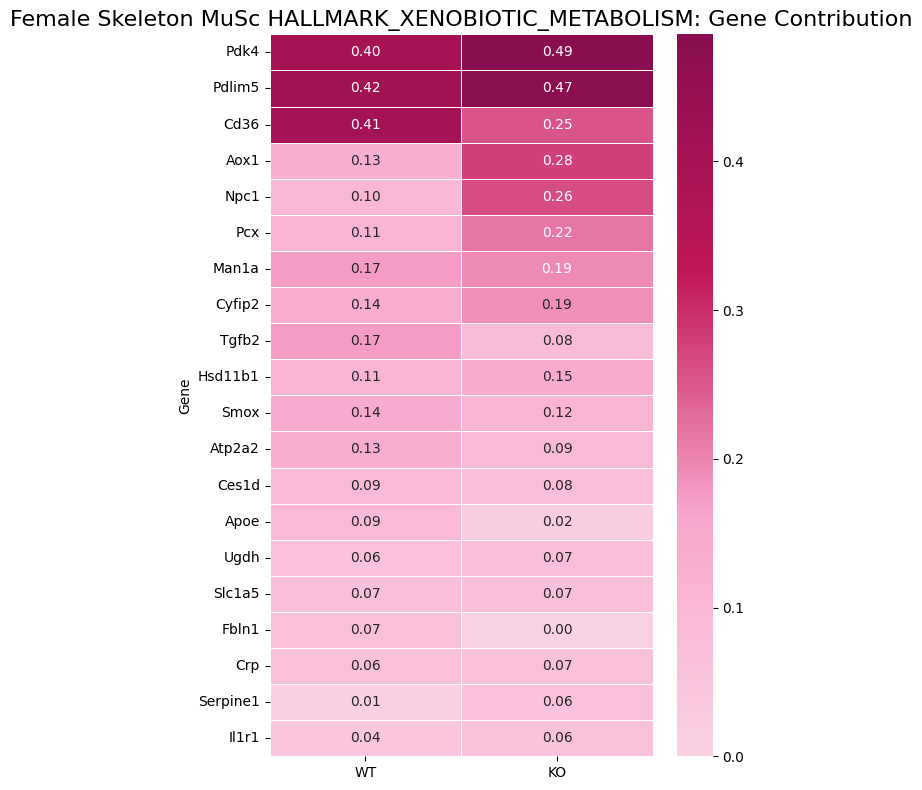

In [ ]:
# subset wt and get gene correlation
adata_subset_wt = pgl.subset_adata_by_obs(adata_subset, filters={"condition": "WT"})
ranked_genes_subset_wt = pgl.compute_gene_correlation_against_score(adata_subset_wt, 
                                                              pgl.get_pathway_genes(pathway_genes, pathway), 
                                                              score=pathway)
display(ranked_genes_subset_wt.head())

# subset wt and get gene correlation
adata_subset_ko = pgl.subset_adata_by_obs(adata_subset, filters={"condition": "KO"})
ranked_genes_subset_ko = pgl.compute_gene_correlation_against_score(adata_subset_ko, 
                                                              pgl.get_pathway_genes(pathway_genes, pathway), 
                                                              score=pathway)
display(ranked_genes_subset_ko.head())

# specify custom palette
pink_cmap = LinearSegmentedColormap.from_list(
    "high_contrast_pink",
    ["#FAD1E3", "#F8A6CD", "#C2185B", "#880E4F"]
)

# plot gene contribution heatmap
gene_contribution_df, fig_gene_contribution_heatmap, ax_gene_contribution = pgl.plot_gene_contribution_heatmap(
    {"WT": ranked_genes_subset_wt,
     "KO": ranked_genes_subset_ko},
     title=f"{sex} {cell_type} {pathway}: Gene Contribution",
     cmap=pink_cmap
)

# Save Files

In [80]:
# save files as svg (low size)
violin_box_outname = f"{file_prefix}_Violin_Box.svg"
violin_box_outpath = output_dir / violin_box_outname
pgl.save_editable_svg(fig_violin_box, violin_box_outpath)

gene_contribution_outname = f"{file_prefix}_Gene_Contribution.svg"
gene_contribution_outpath = output_dir / gene_contribution_outname
pgl.save_editable_svg(fig_gene_contribution_heatmap, gene_contribution_outpath)

PosixPath('Output/Skeleton MuSc/Female/Metabolic/Skeleton MuSc_F_HALLMARK_XENOBIOTIC_METABOLISM_Score_Gene_Contribution.svg')